<a href="https://colab.research.google.com/github/palarunava/machine-learning-courses/blob/main/tensorflow-developer-professional-certificate/convolution-networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Fashion MNIST Dataset

The [Fashion MNIST dataset](https://github.com/zalandoresearch/fashion-mnist) is a collection of grayscale 28x28 pixel clothing images. Each image is associated with a label as shown in this table.

| Label | Description |
| --- | --- |
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

This dataset is available directly in the [tf.keras.datasets](https://www.tensorflow.org/api_docs/python/tf/keras/datasets) API and you load it like this:

Number of training samples: (60000, 28, 28)
Number of test samples: 10000
Training Sample: 12917
LABEL: 2

IMAGE PIXEL ARRAY:

[[  0   0   0   0   0   0   0   2   2   0   0   0   0   0   0   0   0   0   0   0   0   2   0   0   0   0   0   0]
 [  0   0   0   0   0   0   1   0   0   0  78 156  86  40  32  45  78 164 123   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   1   0   0 103 205 237 249 238 229 233 207 249 249 237 223 165  32   0   0   0   0   0   0]
 [  0   0   0   0   4   0  17 210 239 226 218 219 223 227 226 205 233 221 219 224 234 240  93   0   1   0   0   0]
 [  0   0   0   0   1   0 155 239 213 220 223 219 219 233 242 247 220 220 225 222 214 229 172   0   0   0   0   0]
 [  0   0   0   0   0   0 211 229 220 227 235 239 232 220 216 217 225 227 230 224 219 223 194   0   0   0   0   0]
 [  0   0   0   0   0   0 230 227 221 211 186 187 159 223 244 235 235 223 216 226 215 221 217   0   0   0   0   0]
 [  0   0   0   0   0   0 205 225 226 213 148 156 231 195 180 200 16

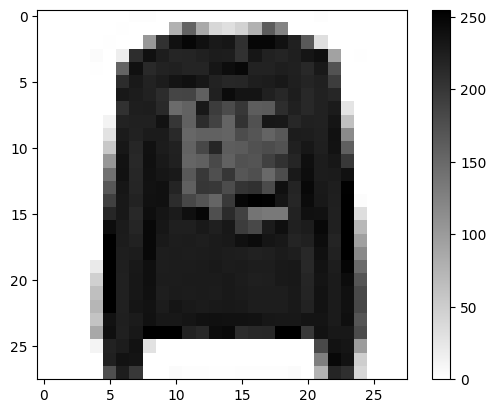

In [2]:
fmnist = tf.keras.datasets.fashion_mnist

# Load the training and test split of the Fashion MNIST dataset
(training_images, training_labels), (test_images, test_labels) = fmnist.load_data()
print(f'Number of training samples: {training_images.shape}')
print(f'Number of test samples: {test_images.shape[0]}')

# You can put between 0 to 59999 here
index = np.random.randint(0, 59999)

# Set number of characters per row when printing
np.set_printoptions(linewidth=320)

# Print the label and image
print(f'Training Sample: {index + 1}')
print(f'LABEL: {training_labels[index]}')
print(f'\nIMAGE PIXEL ARRAY:\n\n{training_images[index]}\n\n')

# Visualize the image using the default colormap (viridis)
# Arg
#   cmp: colormap = 'viridis' by default
plt.imshow(training_images[index], cmap='binary')
plt.colorbar()
plt.show()

# Normalize the pixel values of the train and test images
training_images  = training_images / 255.0
test_images = test_images / 255.0

In [3]:
iterations = 5

# Build the classification model
model = tf.keras.models.Sequential([
  tf.keras.Input(shape=(28,28,1)),
  tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
  tf.keras.layers.MaxPooling2D(2,2),
  tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
  tf.keras.layers.MaxPooling2D(2,2),

  # Same output layers
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(10, activation='softmax')
])

# Print the model summary
model.summary()

model.compile(
  optimizer = tf.optimizers.Adam(),
  loss = 'sparse_categorical_crossentropy',
  metrics=['accuracy']
)

history = model.fit(training_images, training_labels, epochs=iterations)
print(f'History: {history}')

test_loss, test_accuracy = model.evaluate(test_images, test_labels, verbose=0)
print(f'Test loss: {test_loss}')
print(f'Test accuracy: {test_accuracy}')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243,786 (952.29 KB)

 Trainable params: 243,786 (952.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7841 - loss: 0.6004
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8888 - loss: 0.3043
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9061 - loss: 0.2503
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9217 - loss: 0.2114
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9294 - loss: 0.1881
History: <keras.src.callbacks.history.History object at 0x791c85b062d0>
Test loss: 0.25353461503982544
Test accuracy: 0.90829998254776


In [4]:
# Set number of characters per row when printing
np.set_printoptions(
    linewidth=120,
    suppress=True,
    precision=4
)

# There are 10000 test samples
# Get the first 100 test samples
print(f'First 100 labels:\n\n{test_labels[:100]}')

# Display the sample indices for shoes
print(f'\nShoes: {[i for i in range(100) if test_labels[:100][i] == 9]}')

First 100 labels:

[9 2 1 1 6 1 4 6 5 7 4 5 7 3 4 1 2 4 8 0 2 5 7 9 1 4 6 0 9 3 8 8 3 3 8 0 7 5 7 9 6 1 3 7 6 7 2 1 2 2 4 4 5 8 2 2 8 4 8
 0 7 7 8 5 1 1 2 3 9 8 7 0 2 6 2 3 1 2 8 4 1 8 5 9 5 0 3 2 0 6 5 3 6 7 1 8 0 1 4 2]

Shoes: [0, 23, 28, 39, 68, 83]


Model layers:
[<Conv2D name=conv2d, built=True> <MaxPooling2D name=max_pooling2d, built=True> <Conv2D name=conv2d_1, built=True>
 <MaxPooling2D name=max_pooling2d_1, built=True> <Flatten name=flatten, built=True> <Dense name=dense, built=True>
 <Dense name=dense_1, built=True>]



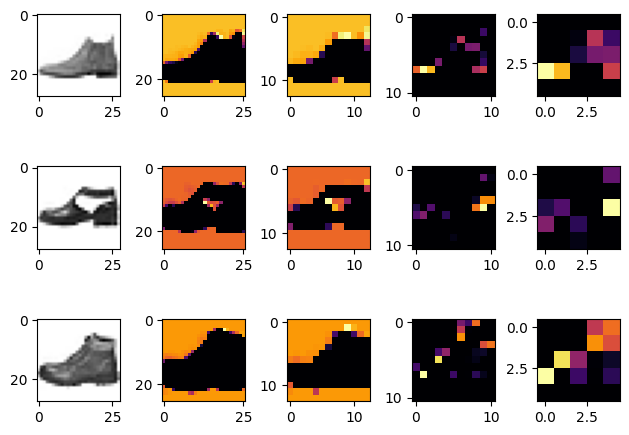

In [7]:
shoes = [i for i in range(100) if test_labels[:100][i] == 9]
FIRST_IMAGE = shoes[0]
SECOND_IMAGE = shoes[1]
THIRD_IMAGE = shoes[2]

# We have configured 64 filters. Choose a number from 0-63.
CONVOLUTION_NUMBER = 10

layers_to_visualize = [tf.keras.layers.Conv2D, tf.keras.layers.MaxPooling2D]

print(f'Model layers:\n{np.array(model.layers)}\n')
layer_outputs = [layer.output for layer in model.layers if type(layer) in layers_to_visualize]
activation_model = tf.keras.models.Model(inputs = model.inputs, outputs = layer_outputs)

f, axarr = plt.subplots(3, len(layer_outputs) + 1)

# Plot the actual image
axarr[0,0].imshow(test_images[FIRST_IMAGE], cmap='binary')
axarr[0,0].grid(False)
axarr[1,0].imshow(test_images[SECOND_IMAGE], cmap='binary')
axarr[0,0].grid(False)
axarr[2,0].imshow(test_images[THIRD_IMAGE], cmap='binary')
axarr[0,0].grid(False)

for x in range(0, len(layer_outputs)):
    f1 = activation_model.predict(test_images[FIRST_IMAGE].reshape(1, 28, 28, 1), verbose=False)[x]
    axarr[0,x+1].imshow(f1[0, :, :, CONVOLUTION_NUMBER], cmap='inferno')
    axarr[0,x+1].grid(False)

    f2 = activation_model.predict(test_images[SECOND_IMAGE].reshape(1, 28, 28, 1), verbose=False)[x]
    axarr[1,x+1].imshow(f2[0, :, :, CONVOLUTION_NUMBER], cmap='inferno')
    axarr[1,x+1].grid(False)

    f3 = activation_model.predict(test_images[THIRD_IMAGE].reshape(1, 28, 28, 1), verbose=False)[x]
    axarr[2,x+1].imshow(f3[0, :, :, CONVOLUTION_NUMBER], cmap='inferno')
    axarr[2,x+1].grid(False)

plt.tight_layout()